<div class="jumbotron text-left"><b>
    
This tutorial describes how to use de DesignSpace within the SMT toolbox.
<div>
    
    February 2026 - `SMT version 2.10.1`
  
     Paul Saves (IRIT/SMAC), Jasper Bussemaker (DLR), Rémi Lafage (ONERA/DTIS/MIDL) and Nathalie BARTOLI (ONERA/DTIS/M2CI)

<div class="alert alert-info fade in" id="d110">
<p>Some updates</p>
<ol> -  Manipulation of mixed DOE (continuous, integer,  categorical and hierarchical variables) </ol>
</div>

<p class="alert alert-success" style="padding:1em">
To use SMT models, please follow this link : https://github.com/SMTorg/SMT/blob/master/README.md. The documentation is available here: http://smt.readthedocs.io/en/latest/
</p>

The reference paper is available
here https://www.sciencedirect.com/science/article/pii/S096599782300162X



For mixed integer with continuous relaxation, the reference paper is available here https://www.sciencedirect.com/science/article/pii/S0925231219315619

In [6]:
# to have the latest version
!pip install configspace
!pip install adsg-core
!pip install smt-design-space-ext
!pip install smt


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


<div class="alert alert-warning" >
If you use hierarchical variables and the size of your doe greater than 30 points, you may leverage the `numba` JIT compiler to speed up the computation
To do so:
    
 - install numba library
    
     `pip install numba`
    
    
 - and define the environment variable `USE_NUMBA_JIT = 1` (unset or 0 if you do not want to use numba)
    
     - Linux: export USE_NUMBA_JIT = 1
    
     - Windows: set USE_NUMBA_JIT = 1

</div>

In [7]:
%matplotlib inline

# to ignore warning messages
import warnings

import plotly.io as pio

from smt_design_space_ext import (
    AdsgDesignSpaceImpl,
    CategoricalVariable,
    ConfigSpaceDesignSpaceImpl,
    DesignSpace,
    FloatVariable,
    IntegerVariable,
    OrdinalVariable,
)

warnings.filterwarnings("ignore")

pio.renderers.default = "notebook"

# MAELIA

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from smt.design_space import FloatVariable, OrdinalVariable, CategoricalVariable
from smt_design_space_ext import AdsgDesignSpaceImpl
from smt.surrogate_models import KRG

# ==========================================
# 1. PARAMÈTRES ET "VALUE TAGGING"
# ==========================================
# On rend TOUTES les variables discrètes uniques pour neutraliser le mélange de l'ADSG
prepa_types = ["Labour", "Preparation du lit de semence", "Déchaumage", "Roulage"]
ferti_types = ["N_solution", "AN", "mineral", "urea"]

agri_design_space = AdsgDesignSpaceImpl(
    design_variables=[
        # --- BLOC DISCRET (Avec Tags Uniques) ---
        OrdinalVariable(["0_ferti", "1_ferti", "2_ferti", "3_ferti"]), # 0: n_ferti
        OrdinalVariable(["Non_prepa", "Oui_prepa"]),                   # 1: has_prepa 
        OrdinalVariable(["1_prepa", "2_prepa"]),                       # 2: nb_prepa 
        CategoricalVariable([p + "_p1" for p in prepa_types]),         # 3: prepa_1
        CategoricalVariable([p + "_p2" for p in prepa_types]),         # 4: prepa_2 
        
        OrdinalVariable(["1_f1", "2_f1"]),                             # 5: Nb produits F1
        CategoricalVariable([f + "_f11" for f in ferti_types]),        # 6: type F1_1
        CategoricalVariable([f + "_f12" for f in ferti_types]),        # 7: type F1_2
        
        OrdinalVariable(["1_f2", "2_f2"]),                             # 8: Nb produits F2
        CategoricalVariable([f + "_f21" for f in ferti_types]),        # 9: type F2_1
        CategoricalVariable([f + "_f22" for f in ferti_types]),        # 10: type F2_2
        
        OrdinalVariable(["1_f3", "2_f3"]),                             # 11: Nb produits F3
        CategoricalVariable([f + "_f31" for f in ferti_types]),        # 12: type F3_1
        CategoricalVariable([f + "_f32" for f in ferti_types]),        # 13: type F3_2
        
        # --- BLOC CONTINU (L'ADSG préserve leur ordre relatif à la fin) ---
        FloatVariable(1, 300),                  # 14: Semi_date
        FloatVariable(1, 100),                  # 15: Jours Semi -> PREPA
        FloatVariable(1, 100),                  # 16: Jours op_precedente -> F1
        FloatVariable(1, 100),                  # 17: Jours F1 -> F2
        FloatVariable(1, 100),                  # 18: Jours F2 -> F3
        FloatVariable(1, 200),                  # 19: Jours dernière op -> Recolte
        FloatVariable(10, 100),                 # 20: dose F1_1
        FloatVariable(10, 100),                 # 21: dose F1_2
        FloatVariable(10, 100),                 # 22: dose F2_1
        FloatVariable(10, 100),                 # 23: dose F2_2
        FloatVariable(10, 100),                 # 24: dose F3_1
        FloatVariable(10, 100),                 # 25: dose F3_2
    ]
)

# ==========================================
# 2. HIÉRARCHIE D'ACTIVATION (ADSG)
# ==========================================
# Les meta_value doivent correspondre à nos nouveaux Tags Uniques
agri_design_space.declare_decreed_var(decreed_var=2,  meta_var=1, meta_value=["Oui_prepa"])
agri_design_space.declare_decreed_var(decreed_var=3,  meta_var=1, meta_value=["Oui_prepa"])
agri_design_space.declare_decreed_var(decreed_var=15, meta_var=1, meta_value=["Oui_prepa"])
agri_design_space.declare_decreed_var(decreed_var=4,  meta_var=2, meta_value=["2_prepa"])

agri_design_space.declare_decreed_var(decreed_var=16, meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=5,  meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=6,  meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=20, meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=7,  meta_var=5, meta_value=["2_f1"])
agri_design_space.declare_decreed_var(decreed_var=21, meta_var=5, meta_value=["2_f1"])

agri_design_space.declare_decreed_var(decreed_var=17, meta_var=0, meta_value=["2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=8,  meta_var=0, meta_value=["2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=9,  meta_var=0, meta_value=["2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=22, meta_var=0, meta_value=["2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=10, meta_var=8, meta_value=["2_f2"])
agri_design_space.declare_decreed_var(decreed_var=23, meta_var=8, meta_value=["2_f2"])

agri_design_space.declare_decreed_var(decreed_var=18, meta_var=0, meta_value=["3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=11, meta_var=0, meta_value=["3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=12, meta_var=0, meta_value=["3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=24, meta_var=0, meta_value=["3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=13, meta_var=11, meta_value=["2_f3"])
agri_design_space.declare_decreed_var(decreed_var=25, meta_var=11, meta_value=["2_f3"])


# ==========================================
# 3. MOTEUR D'EXTRACTION BLINDÉ
# ==========================================
def parse_smt_row(row_data):
    """ Analyse une ligne décodée par SMT en cherchant nos tags uniques """
    parsed = {
        "n_ferti": 0, "has_prepa": False, "nb_prepa": 1, "nb_f1": 1, "nb_f2": 1, "nb_f3": 1,
        "prepa_t1": "-", "prepa_t2": "-", "f1_t1": "-", "f1_t2": "-", 
        "f2_t1": "-", "f2_t2": "-", "f3_t1": "-", "f3_t2": "-", "floats": []
    }
    
    # Sécurise la lecture si SMT renvoie un dictionnaire ou une liste
    values = list(row_data.values()) if isinstance(row_data, dict) else row_data
    
    for val in values:
        if isinstance(val, (float, int)):
            parsed["floats"].append(float(val))
        elif isinstance(val, str):
            if "_ferti" in val: parsed["n_ferti"] = int(val[0])
            elif val in ["Oui_prepa", "Non_prepa"]: parsed["has_prepa"] = (val == "Oui_prepa")
            elif "_prepa" in val: parsed["nb_prepa"] = int(val[0])
            elif "_p1" in val: parsed["prepa_t1"] = val.replace("_p1", "")
            elif "_p2" in val: parsed["prepa_t2"] = val.replace("_p2", "")
            elif "_f11" in val: parsed["f1_t1"] = val.replace("_f11", "")
            elif "_f12" in val: parsed["f1_t2"] = val.replace("_f12", "")
            elif val in ["1_f1", "2_f1"]: parsed["nb_f1"] = int(val[0])
            elif "_f21" in val: parsed["f2_t1"] = val.replace("_f21", "")
            elif "_f22" in val: parsed["f2_t2"] = val.replace("_f22", "")
            elif val in ["1_f2", "2_f2"]: parsed["nb_f2"] = int(val[0])
            elif "_f31" in val: parsed["f3_t1"] = val.replace("_f31", "")
            elif "_f32" in val: parsed["f3_t2"] = val.replace("_f32", "")
            elif val in ["1_f3", "2_f3"]: parsed["nb_f3"] = int(val[0])
            
    return parsed

def extract_table_from_smt(x_array, dsg_space):
    results = []
    decoded_data = dsg_space.decode_values(x_array)
    
    for row_data in decoded_data:
        p = parse_smt_row(row_data)
        fl = p["floats"] # Les 12 variables continues restent toujours dans leur ordre
        
        semi = int(round(fl[0]))
        if p["has_prepa"]:
            prepa_date = int(round(semi + fl[1]))
            p2 = p["prepa_t2"] if p["nb_prepa"] == 2 else "-"
        else:
            prepa_date = None
            p["prepa_t1"] = p2 = "-"

        base_f1 = prepa_date if p["has_prepa"] else semi
        
        if p["n_ferti"] >= 1:
            f1_date = int(round(base_f1 + fl[2]))
            f1_d1 = round(fl[6], 1)
            f1_t2 = p["f1_t2"] if p["nb_f1"] == 2 else "-"
            f1_d2 = round(fl[7], 1) if p["nb_f1"] == 2 else "-"
        else:
            f1_date = None
            p["f1_t1"] = f1_d1 = f1_t2 = f1_d2 = "-"

        if p["n_ferti"] >= 2:
            f2_date = int(round(f1_date + fl[3]))
            f2_d1 = round(fl[8], 1)
            f2_t2 = p["f2_t2"] if p["nb_f2"] == 2 else "-"
            f2_d2 = round(fl[9], 1) if p["nb_f2"] == 2 else "-"
        else:
            f2_date = None
            p["f2_t1"] = f2_d1 = f2_t2 = f2_d2 = "-"

        if p["n_ferti"] >= 3:
            f3_date = int(round(f2_date + fl[4]))
            f3_d1 = round(fl[10], 1)
            f3_t2 = p["f3_t2"] if p["nb_f3"] == 2 else "-"
            f3_d2 = round(fl[11], 1) if p["nb_f3"] == 2 else "-"
        else:
            f3_date = None
            p["f3_t1"] = f3_d1 = f3_t2 = f3_d2 = "-"

        last_date = f3_date if f3_date else (f2_date if f2_date else (f1_date if f1_date else (prepa_date if prepa_date else semi)))
        recolte = int(round(last_date + fl[5]))

        results.append({
            "n_ferti": p["n_ferti"], "has_prepa": "Oui" if p["has_prepa"] else "Non", "Semi": semi,
            "PREPA_Date": prepa_date if p["has_prepa"] else "-", "PREPA_Type_1": p["prepa_t1"], "PREPA_Type_2": p2,
            "Ferti_1": f1_date if f1_date else "-", "F1_Type_1": p["f1_t1"], "F1_Dose_1": f1_d1, "F1_Type_2": f1_t2, "F1_Dose_2": f1_d2,
            "Ferti_2": f2_date if f2_date else "-", "F2_Type_1": p["f2_t1"], "F2_Dose_1": f2_d1, "F2_Type_2": f2_t2, "F2_Dose_2": f2_d2,
            "Ferti_3": f3_date if f3_date else "-", "F3_Type_1": p["f3_t1"], "F3_Dose_1": f3_d1, "F3_Type_2": f3_t2, "F3_Dose_2": f3_d2,
            "Recolte": recolte
        })

    return pd.DataFrame(results)

# ==========================================
# 4. GESTION DES DONNÉES (MAELIA DUMMY)
# ==========================================
def evaluate_maelia_dummy(x_array, dsg_space):
    y = np.zeros((x_array.shape[0], 1))
    decoded_data = dsg_space.decode_values(x_array)
    
    for i, row_data in enumerate(decoded_data):
        p = parse_smt_row(row_data)
        fl = p["floats"]
        dose_totale = 0
        
        if p["n_ferti"] >= 1:
            dose_totale += fl[6]
            if p["nb_f1"] == 2: dose_totale += fl[7]
        if p["n_ferti"] >= 2:
            dose_totale += fl[8]
            if p["nb_f2"] == 2: dose_totale += fl[9]
        if p["n_ferti"] >= 3:
            dose_totale += fl[10]
            if p["nb_f3"] == 2: dose_totale += fl[11]
            
        y[i, 0] = 50 + (dose_totale * 0.25) - (0.0006 * dose_totale**2) + 0.1#np.random.normal(0, 1.5)
    return y


# ==========================================
# 5. ENTRAÎNEMENT & VALIDATION (KRIGEAGE)
# ==========================================
print("Génération de 100 échantillons d'entraînement...")
xt, is_acting_t, dsg_samples = agri_design_space._sample_valid_x(30, return_render=True)
yt = evaluate_maelia_dummy(xt, agri_design_space)

print("\nAperçu du Plan d'Expérience (DOE) parfait :")
display(extract_table_from_smt(xt[:30], agri_design_space))

# print(xt[:30])
# print(is_acting_t[:30])
# for i in  dsg_samples : 
#     i.render()


Génération de 100 échantillons d'entraînement...

Aperçu du Plan d'Expérience (DOE) parfait :


,n_ferti,has_prepa,Semi,PREPA_Date,PREPA_Type_1,PREPA_Type_2,Ferti_1,F1_Type_1,F1_Dose_1,F1_Type_2,...,F2_Type_1,F2_Dose_1,F2_Type_2,F2_Dose_2,Ferti_3,F3_Type_1,F3_Dose_1,F3_Type_2,F3_Dose_2,Recolte
0,0,Non,271,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,447
1,0,Non,131,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,315
2,1,Oui,157,170,Roulage,Labour,226,N_solution,27.0,urea,...,-,-,-,-,-,-,-,-,-,416
3,0,Non,72,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,264
4,2,Oui,18,24,Déchaumage,Roulage,39,N_solution,28.5,N_solution,...,N_solution,82.2,urea,49.6,-,-,-,-,-,171
5,1,Oui,68,147,Preparationdulitdesemence,-,230,AN,74.2,N_solution,...,-,-,-,-,-,-,-,-,-,277
6,1,Oui,59,151,Roulage,-,241,AN,88.6,-,...,-,-,-,-,-,-,-,-,-,410
7,0,Non,103,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,274
8,2,Non,5,-,-,-,68,N_solution,50.1,-,...,mineral,99.5,-,-,-,-,-,-,-,196
9,0,Oui,133,161,Déchaumage,Roulage,-,-,-,-,...,-,-,-,-,-,-,-,-,-,269


=== GRAPHE GLOBAL DE L'ESPACE DE CONCEPTION ===


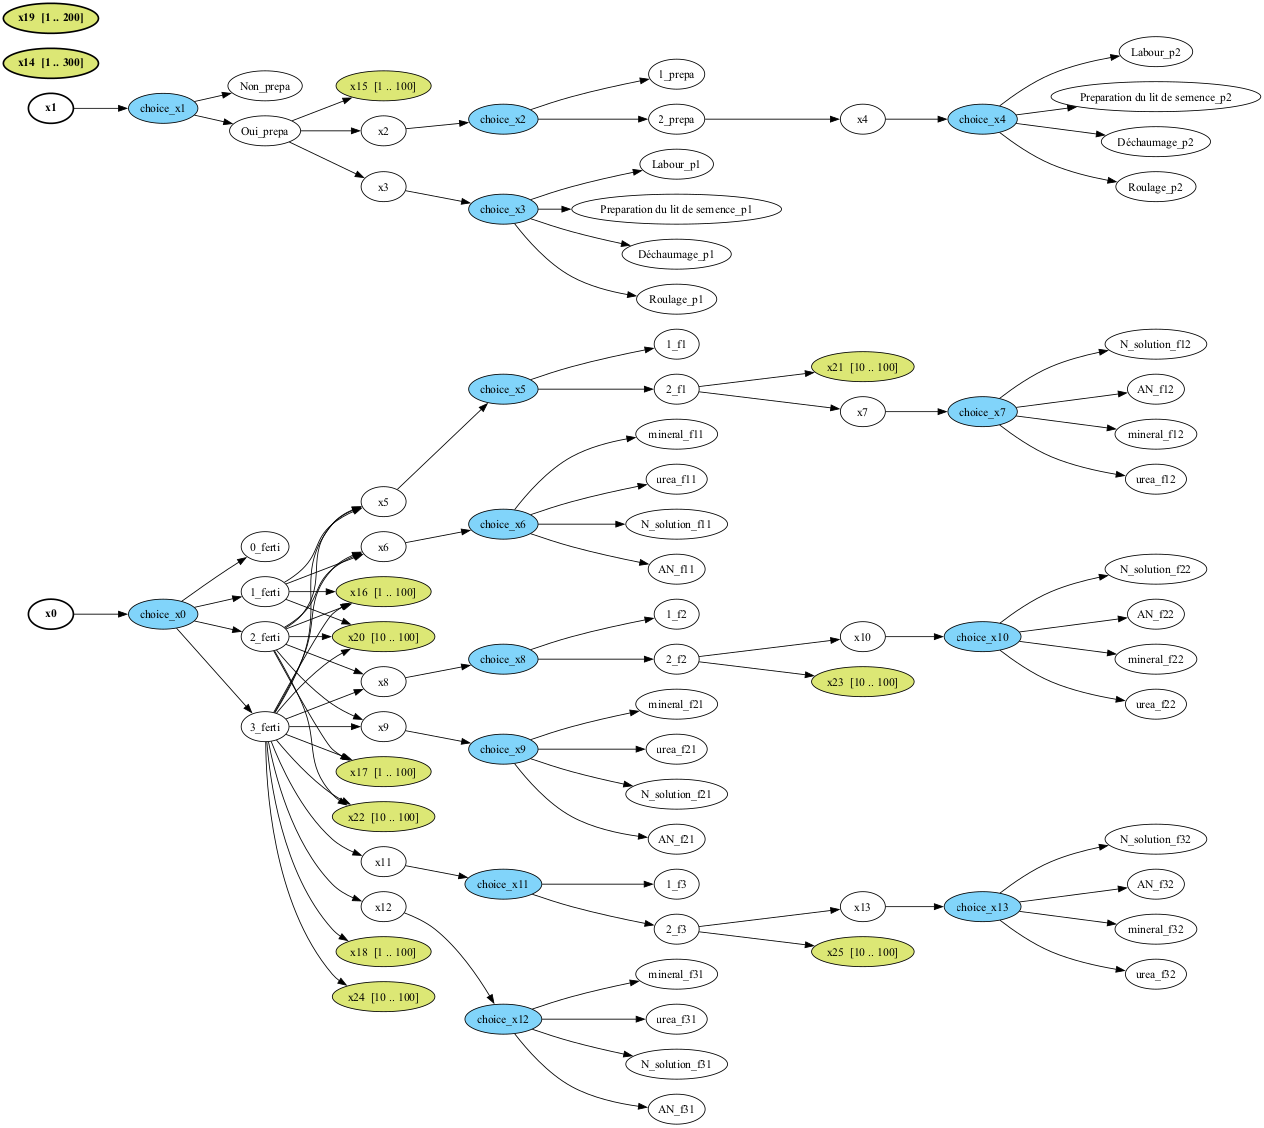

In [10]:
import os
import subprocess
from IPython.display import Image, display

# Configuration du chemin vers Graphviz
os.environ["PATH"] += os.pathsep + "/Users/benjamin/miniconda3/bin"

def render_to_image(dsg_obj, filename="temp_graph"):
    # 1. Export au format DOT (texte)
    dot_str = dsg_obj.export_dot()
    with open(f"{filename}.dot", "w") as f:
        f.write(dot_str)
    
    # 2. Conversion DOT -> PNG via la commande système 'dot'
    subprocess.run(["dot", "-Tpng", f"{filename}.dot", "-o", f"{filename}.png"])
    
    # 3. Affichage de l'image
    display(Image(filename=f"{filename}.png"))

print("=== GRAPHE GLOBAL DE L'ESPACE DE CONCEPTION ===")
render_to_image(agri_design_space.adsg, "maelia_space")


In [5]:
print("\nEntraînement du Krigeage Hiérarchique SMT (KRG)...")
sm = KRG(design_space=agri_design_space, print_global=False)
sm.set_training_values(xt, yt)
sm.train()
print("Modèle entraîné !")



Entraînement du Krigeage Hiérarchique SMT (KRG)...
Modèle entraîné !


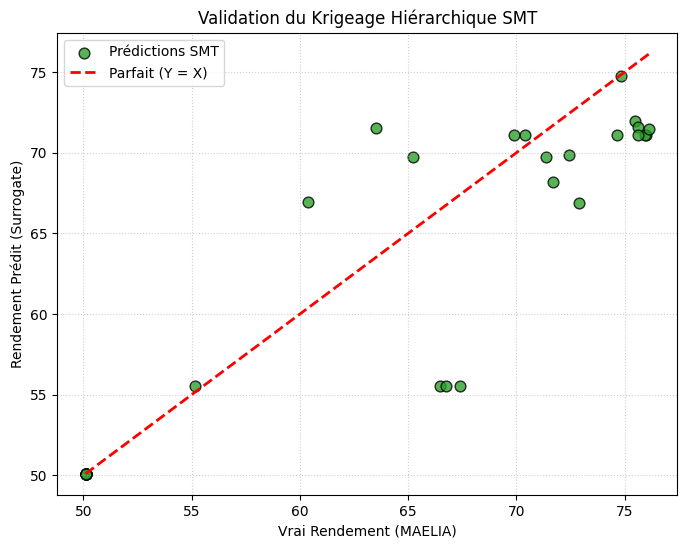

In [20]:

xtest, is_acting_test = agri_design_space._sample_valid_x(30)
ytest_vrai = evaluate_maelia_dummy(xtest, agri_design_space)
ytest_predit = sm.predict_values(xtest)

plt.figure(figsize=(8, 6))
plt.scatter(ytest_vrai, ytest_predit, color='#2ca02c', edgecolors='k', s=60, alpha=0.8, label="Prédictions SMT")
plt.plot([ytest_vrai.min(), ytest_vrai.max()], [ytest_vrai.min(), ytest_vrai.max()], 'r--', lw=2, label="Parfait (Y = X)")
plt.xlabel("Vrai Rendement (MAELIA)")
plt.ylabel("Rendement Prédit (Surrogate)")
plt.title("Validation du Krigeage Hiérarchique SMT")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

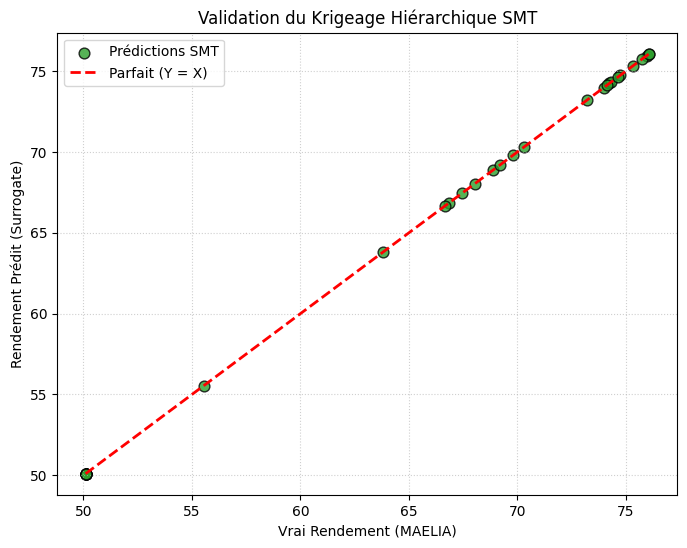

In [21]:
ytest_vrai = evaluate_maelia_dummy(xt, agri_design_space)
ytest_predit = sm.predict_values(xt)

plt.figure(figsize=(8, 6))
plt.scatter(ytest_vrai, ytest_predit, color='#2ca02c', edgecolors='k', s=60, alpha=0.8, label="Prédictions SMT")
plt.plot([ytest_vrai.min(), ytest_vrai.max()], [ytest_vrai.min(), ytest_vrai.max()], 'r--', lw=2, label="Parfait (Y = X)")
plt.xlabel("Vrai Rendement (MAELIA)")
plt.ylabel("Rendement Prédit (Surrogate)")
plt.title("Validation du Krigeage Hiérarchique SMT")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [14]:
agri_design_space.render()

AttributeError: 'AdsgDesignSpaceImpl' object has no attribute 'render'